In [21]:
from __future__ import annotations

import sys
from pathlib import Path
from uuid import uuid4

import pandas as pd
from IPython.display import Image, display
from rich import print as rprint

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = next(parent for parent in ROOT.parents if (parent / "src").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.application.bootstrap import bootstrap_project_environment, load_environment
from src.application.project_config import load_project_config
from src.application.settings import ViRAGESettings
from src.infrastructure.runtime import RuntimeContext
from src.llm.factory import build_chat_model
from src.services.chart_generator import ChartGeneratorService
from src.services.data_preparation import DataPreparationService
from src.services.data_profiler import DataProfilerService
from src.services.query_request_analyzer import QueryRequestAnalyzerService
from src.services.spec_validator import SpecValidatorService
from src.services.vegalite_plot_drawing import VegaLitePlotDrawingService
from src.services.visrag import VisRAGService

bootstrap_project_environment()
load_environment(ROOT/".env")

CONFIG_PATH = ROOT / "ui/config/app/project-gemma4.toml"
DATA_PATH = ROOT / "demo_data/Iris.csv"
RUNTIME_CORPUS_PATH = ROOT / "rag_corpus/runtime/virage_rules.jsonl"
QUERY = "Show the distribution of PetalLengthCm for each Species in the iris dataset."
RUN_ID = f"notebook_iris_demo_{uuid4().hex[:8]}"

config = load_project_config(CONFIG_PATH)
settings: ViRAGESettings = config.settings.model_copy(deep=True)
settings.artifact_root = ROOT / "artifacts/notebooks"
settings.semantic_feedback_loop_enabled = False
settings.enable_spec_score = False
settings.enable_vision_score = False
settings.enable_evaluation_summary = False
settings.visrag_enabled = True
settings.visrag_corpus_root = ROOT / "rag_corpus/runtime"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Demo dataset was not found: {DATA_PATH}")
if not RUNTIME_CORPUS_PATH.exists():
    raise FileNotFoundError(
        f"Runtime RAG corpus was not found: {RUNTIME_CORPUS_PATH}. "
        "Run: python scripts/rag_corpus/run_export_runtime.py --profile validated"
    )

runtime = RuntimeContext(
    settings=settings,
    reasoning_llm=build_chat_model(config.reasoning_model),
    spec_llm=build_chat_model(config.spec_model),
)
runtime.current_run_id = RUN_ID
runtime.reset_artifact_indices(run_id=RUN_ID)
runtime.ensure_run_dir(RUN_ID)

rprint({
    "project_root": ROOT.as_posix(),
    "config": CONFIG_PATH.relative_to(ROOT).as_posix(),
    "data_path": DATA_PATH.relative_to(ROOT).as_posix(),
    "runtime_corpus": RUNTIME_CORPUS_PATH.relative_to(ROOT).as_posix(),
    "query": QUERY,
    "run_id": RUN_ID,
})

{
    'project_root': 'D:/programming/projects/ViRAGE',
    'config': 'ui/config/app/project-gemma4.toml',
    'data_path': 'demo_data/Iris.csv',
    'runtime_corpus': 'rag_corpus/runtime/virage_rules.jsonl',
    'query': 'Show the distribution of PetalLengthCm for each Species in the iris dataset.',
    'run_id': 'notebook_iris_demo_65d023bb'
}

In [22]:
data_profile = DataProfilerService().invoke(DATA_PATH.as_posix(), runtime=runtime)
df = runtime.read_dataframe(DATA_PATH)

rprint({
    "step": "data_profile",
    "shape": df.shape,
    "columns": list(df.columns),
    "preview": df.head(5).to_dict(orient="records"),
    "profile": data_profile.model_dump(mode="json"),
})

{
    'step': 'data_profile',
    'shape': (150, 6),
    'columns': ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species'],
    'preview': [
        {
            'Id': 1,
            'SepalLengthCm': 5.1,
            'SepalWidthCm': 3.5,
            'PetalLengthCm': 1.4,
            'PetalWidthCm': 0.2,
            'Species': 'Iris-setosa'
        },
        {
            'Id': 2,
            'SepalLengthCm': 4.9,
            'SepalWidthCm': 3.0,
            'PetalLengthCm': 1.4,
            'PetalWidthCm': 0.2,
            'Species': 'Iris-setosa'
        },
        {
            'Id': 3,
            'SepalLengthCm': 4.7,
            'SepalWidthCm': 3.2,
            'PetalLengthCm': 1.3,
            'PetalWidthCm': 0.2,
            'Species': 'Iris-setosa'
        },
        {
            'Id': 4,
            'SepalLengthCm': 4.6,
            'SepalWidthCm': 3.1,
            'PetalLengthCm': 1.5,
            'PetalWidthCm': 0.2,
            'Species': 'Iris-setosa'
        },
        {
            'Id': 5,
            'SepalLengthCm': 5.0,
            'SepalWidthCm': 3.6,
            'PetalLengthCm': 1.4,
            'PetalWidthCm': 0.2,
            'Species': 'Iris-setosa'
        }
    ],
    'profile': {
        'row_count': 150,
        'col_count': 6,
        'columns': [
            {
                'name': 'Id',
                'dtype': 'numeric',
                'role': 'identifier',
                'missing_ratio': 0.0,
                'unique_count': 150,
                'safe_name': 'Id',
                'min_value': 1.0,
                'max_value': 150.0,
                'sample_values': [74, 19, 119, 79, 77],
                'outlier_count': 0,
                'outlier_ratio': 0.0,
                'is_identifier': True,
                'is_high_cardinality': False,
                'raw_dtype': 'int64',
                'missing_like_ratio': 0.0,
                'quality_flags': ['identifier_like'],
                'preparation_hints': []
            },
            {
                'name': 'SepalLengthCm',
                'dtype': 'numeric',
                'role': 'measure',
                'missing_ratio': 0.0,
                'unique_count': 35,
                'safe_name': 'SepalLengthCm',
                'min_value': 4.3,
                'max_value': 7.9,
                'sample_values': [6.1, 5.7, 7.7, 6.0, 6.8],
                'outlier_count': 0,
                'outlier_ratio': 0.0,
                'is_identifier': False,
                'is_high_cardinality': False,
                'raw_dtype': 'float64',
                'missing_like_ratio': 0.0,
                'quality_flags': ['good_for_measure'],
                'preparation_hints': []
            },
            {
                'name': 'SepalWidthCm',
                'dtype': 'numeric',
                'role': 'measure',
                'missing_ratio': 0.0,
                'unique_count': 23,
                'safe_name': 'SepalWidthCm',
                'min_value': 2.0,
                'max_value': 4.4,
                'sample_values': [2.8, 3.8, 2.6, 2.9, 2.8],
                'outlier_count': 4,
                'outlier_ratio': 0.02666666666666667,
                'is_identifier': False,
                'is_high_cardinality': False,
                'raw_dtype': 'float64',
                'missing_like_ratio': 0.0,
                'quality_flags': ['good_for_measure'],
                'preparation_hints': []
            },
            {
                'name': 'PetalLengthCm',
                'dtype': 'numeric',
                'role': 'measure',
                'missing_ratio': 0.0,
                'unique_count': 43,
                'safe_name': 'PetalLengthCm',
                'min_value': 1.0,
                'max_value': 6.9,
                'sample_values': [4.7, 1.7, 6.9, 4.5, 4.8],
                'outlier_count': 0,
                'outlier_ratio': 0.0,
                'is_identifier': False,
            

In [23]:
query_request_analysis = QueryRequestAnalyzerService().invoke(
    query=QUERY,
    user_context={"notebook": "iris_demo"},
    data_profile=data_profile,
    runtime=runtime,
)

rprint({
    "step": "query_request_analysis",
    "result": query_request_analysis.model_dump(mode="json"),
})

{
    'step': 'query_request_analysis',
    'result': {
        'normalized_query': 'Show the distribution of PetalLengthCm for each Species in the iris dataset.',
        'analysis_task': 'distribution',
        'recommended_chart_family': 'auto',
        'selected_fields': ['PetalLengthCm', 'Species'],
        'field_bindings': {
            'x': {
                'field': 'PetalLengthCm',
                'role': 'measure_axis',
                'confidence': 1.0,
                'rationale': 'The user wants to see the distribution of this numeric measure.'
            },
            'y': {
                'field': 'Species',
                'role': 'dimension_axis',
                'confidence': 1.0,
                'rationale': "The distribution is requested 'for each Species'."
            }
        },
        'field_mappings': [
            {
                'query_term': 'PetalLengthCm',
                'column_name': 'PetalLengthCm',
                'confidence': 1.0,
                'rationale': 'Exact match with schema.'
            },
            {
                'query_term': 'Species',
                'column_name': 'Species',
                'confidence': 1.0,
                'rationale': 'Exact match with schema.'
            }
        ],
        'aggregation_plan': {'operation': 'distribution', 'column': 'PetalLengthCm', 'group_by': ['Species']},
        'visual_judge_requirements': {
            'must_be_visible': [
                'The chart must show PetalLengthCm on one axis.',
                'The chart must distinguish between the different Species (e.g., via separate plots, colors, or 
axis categories).'
            ],
            'acceptable_visual_encodings': {},
            'critical_failures': [
                'The chart does not group by Species.',
                'The chart shows a single aggregate value (like mean) instead of a distribution.'
            ],
            'yes_no_questions': ['Can I see the spread of PetalLengthCm for each of the three species?']
        },
        'query_variants': [
            {
                'kind': 'canonical',
                'text': 'Show the distribution of PetalLengthCm for each Species in the iris dataset.',
                'confidence': 1.0,
                'source': 'llm'
            },
            {
                'kind': 'chart_pattern_retrieval',
                'text': 'distribution of PetalLengthCm by Species',
                'confidence': 0.9,
                'source': 'llm'
            }
        ],
        'chart_answerability': {
            'status': 'answerable_by_chart',
            'reason': 'Distribution plots (like box plots, histograms, or violin plots) can effectively show the 
spread of a numeric variable across categories.'
        },
        'assumptions': [],
        'ambiguity': {'missing_fields': [], 'notes': [], 'confidence': 1.0},
        'confidence': 1.0
    }
}

In [24]:
data_preparation = DataPreparationService().invoke(
    data_path=DATA_PATH.as_posix(),
    data_profile=data_profile,
    request_analysis=query_request_analysis,
    run_id=RUN_ID,
    runtime=runtime,
)

rprint({
    "step": "data_preparation",
    "result": data_preparation.model_dump(mode="json"),
})

{
    'step': 'data_preparation',
    'result': {
        'output_path': 
'D:/programming/projects/ViRAGE/artifacts/notebooks/notebook_iris_demo_65d023bb/001_cleaned_data.csv',
        'operations': ['preserve_row_multiplicity'],
        'row_count': 150,
        'col_count': 6,
        'column_name_map': {
            'Id': 'Id',
            'SepalLengthCm': 'SepalLengthCm',
            'SepalWidthCm': 'SepalWidthCm',
            'PetalLengthCm': 'PetalLengthCm',
            'PetalWidthCm': 'PetalWidthCm',
            'Species': 'Species'
        },
        'reverse_column_name_map': {
            'Id': 'Id',
            'SepalLengthCm': 'SepalLengthCm',
            'SepalWidthCm': 'SepalWidthCm',
            'PetalLengthCm': 'PetalLengthCm',
            'PetalWidthCm': 'PetalWidthCm',
            'Species': 'Species'
        },
        'original_columns': ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species'],
        'safe_columns': ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species'],
        'renamed_column_count': 0
    }
}

In [25]:
visrag = VisRAGService().invoke(
    query_analysis=query_request_analysis,
    data_profile=data_profile,
    runtime=runtime,
)

retrieved = []
if visrag.debug_retrieval is not None:
    retrieved = [
        {
            "doc_id": doc.doc_id,
            "record_type": doc.record_type,
            "title": doc.title,
            "score": doc.score,
            "source": doc.metadata.get("source_dataset") or doc.metadata.get("source"),
        }
        for doc in visrag.debug_retrieval.retrieved_documents
    ]

rprint({
    "step": "visrag",
    "corpus_status": visrag.corpus_status,
    "retrieved": retrieved,
    "guidance_prompt_text": visrag.generation_guidance.prompt_text,
})

{
    'step': 'visrag',
    'corpus_status': {
        'enabled': True,
        'documents': 274,
        'backend': 'jsonl',
        'signature': {
            'backend': 'jsonl',
            'uri': 'D:\\programming\\projects\\ViRAGE\\rag_corpus\\runtime',
            'resolved_path': 'D:/programming/projects/ViRAGE/rag_corpus/runtime/virage_rules.jsonl',
            'exists': True,
            'size_bytes': 214154,
            'mtime_ns': 1779550686000000000,
            'hash': 'caaebecfe59cfe8a681d7110d12469feb6ed7647a27934a9522d55cd9b3a9f8e',
            'cache_key': 
'jsonl:D:/programming/projects/ViRAGE/rag_corpus/runtime/virage_rules.jsonl:1779550686000000000:214154:caaebecfe59c
fe8a681d7110d12469feb6ed7647a27934a9522d55cd9b3a9f8e',
            'document_count': 274
        }
    },
    'retrieved': [
        {
            'doc_id': 'chart_pattern__vega_lite_examples__bar_chart_for_age_distribution__0417c6218b',
            'record_type': 'chart_pattern',
            'title': 'Bar Chart for Age Distribution',
            'score': 100.439359,
            'source': 'vega_lite_examples'
        },
        {
            'doc_id': 'chart_pattern__vega_lite_examples__bar_chart_with_binned_data__55c1389772',
            'record_type': 'chart_pattern',
            'title': 'Bar Chart with Binned Data',
            'score': 85.995333,
            'source': 'vega_lite_examples'
        },
        {
            'doc_id': 'readability_rule__vega_lite_examples__clear_labels_and_legends__739217b521',
            'record_type': 'readability_rule',
            'title': 'Clear Labels and Legends',
            'score': 46.117823,
            'source': 'vega_lite_examples'
        },
        {
            'doc_id': 'readability_rule__vega_lite_examples__use_clear_titles_and_labels__d4e24d9aef',
            'record_type': 'readability_rule',
            'title': 'Use Clear Titles and Labels',
            'score': 38.803900999999996,
            'source': 'vega_lite_examples'
        },
        {
            'doc_id': 'scale_plot_area_rule__vega_lite_examples__optimize_plot_area_for_bar_charts__199c6f6742',
            'record_type': 'scale_plot_area_rule',
            'title': 'Optimize Plot Area for Bar Charts',
            'score': 52.876372,
            'source': 'vega_lite_examples'
        },
        {
            'doc_id': 'vlm_readability_rule__vega_lite_examples__static_png_readability_in_bar_charts__97e6e23048',
            'record_type': 'vlm_readability_rule',
            'title': 'Static-PNG Readability in Bar Charts',
            'score': 34.711805999999996,
            'source': 'vega_lite_examples'
        },
        {
            'doc_id': 'vlm_readability_rule__vega_lite_examples__ensure_static_png_readability__2b041dcebb',
            'record_type': 'vlm_readability_rule',
            'title': 'Ensure Static-PNG Readability',
            'score': 34.271269000000004,
            'source': 'vega_lite_examples'
        },
        {
            'doc_id': 'domain_semantics_rule__vega_lite_examples__age_group_categories__5117cdb722',
            'record_type': 'domain_semantics_rule',
            'title': 'Age Group Categories',
            'score': 67.434305,
            'source': 'vega_lite_examples'
        }
    ],
    'guidance_prompt_text': 'VisRAG rule guidance:\n- Query analysis is the source of truth for task, selected 
fields, chart family, and aggregation. Use retrieved rules only as supporting guidance.\n- Target chart family: 
auto; task: distribution.\n- Create a bar chart showing US population by age groups in 2000.\n- Create a bar chart 
showing the distribution of data in bins.\n- Label each category clearly and add a legend if needed.\n- Label all 
elements of your chart clearly.\n- Utilize the plot area efficiently.\n- Ensure static-PNG images of bar charts are
readable.\n- Check chart readability for static PNG export.\n- Define the age group categories for the US 
population distribution.'
}

In [26]:
vega_spec = ChartGeneratorService().invoke(
    prepared=data_preparation,
    runtime=runtime,
    query=QUERY,
    data_profile=data_profile,
    query_request_analysis=query_request_analysis,
    visrag=visrag,
    generation_attempt_number=1,
    max_generation_attempts=1,
    visual_judge_requirements=query_request_analysis.visual_judge_requirements,
)

rprint({
    "step": "chart_generation",
    "backend": vega_spec.generation_backend,
    "warnings": vega_spec.generation_warnings,
    "explanation": vega_spec.generation_explanation,
    "spec": vega_spec.spec_json,
})

{
    'step': 'chart_generation',
    'backend': 'vegachat_codegen',
    'warnings': [
        "Set encoding.y.axis.title to 'Petal Length Cm'.",
        "Set encoding.color.legend.title to 'Species'.",
        "Set encoding.tooltip.title to 'Species'.",
        "Set encoding.tooltip.title to 'Petal Length Cm'.",
        'Removed redundant color legend because color duplicates x field.',
        "Set chart title to 'Petal Length Cm Distribution by Species'."
    ],
    'explanation': 'I will create a box plot to show the distribution of PetalLengthCm for each Species. A box plot
is ideal for comparing the spread, median, and quartiles of a numeric measure across different categories.',
    'spec': {
        '$schema': 'https://vega.github.io/schema/vega-lite/v5.json',
        'description': 'Distribution of Petal Length by Species',
        'mark': {'type': 'boxplot', 'extent': 'min-max'},
        'encoding': {
            'x': {'field': 'Species', 'type': 'nominal', 'axis': {'title': 'Species'}},
            'y': {'field': 'PetalLengthCm', 'type': 'quantitative', 'axis': {'title': 'Petal Length Cm'}},
            'color': {'field': 'Species', 'type': 'nominal', 'legend': None},
            'tooltip': [
                {'field': 'Species', 'type': 'nominal', 'title': 'Species'},
                {'field': 'PetalLengthCm', 'type': 'quantitative', 'title': 'Petal Length Cm'}
            ]
        },
        'data': {
            'url': 
'D:/programming/projects/ViRAGE/artifacts/notebooks/notebook_iris_demo_65d023bb/001_cleaned_data.csv'
        },
        'title': 'Petal Length Cm Distribution by Species'
    }
}

In [27]:
spec_validation = SpecValidatorService().invoke(vega_spec, runtime=runtime)

rprint({
    "step": "spec_validation",
    "is_valid": spec_validation.is_valid,
    "errors": spec_validation.validation_errors,
    "repair_hints": spec_validation.repair_hints,
    "validated_spec": spec_validation.validated_spec,
})

{
    'step': 'spec_validation',
    'is_valid': True,
    'errors': [],
    'repair_hints': [],
    'validated_spec': {
        '$schema': 'https://vega.github.io/schema/vega-lite/v5.json',
        'description': 'Distribution of Petal Length by Species',
        'mark': {'type': 'boxplot', 'extent': 'min-max'},
        'encoding': {
            'x': {'field': 'Species', 'type': 'nominal', 'axis': {'title': 'Species'}},
            'y': {'field': 'PetalLengthCm', 'type': 'quantitative', 'axis': {'title': 'Petal Length Cm'}},
            'color': {'field': 'Species', 'type': 'nominal', 'legend': None},
            'tooltip': [
                {'field': 'Species', 'type': 'nominal', 'title': 'Species'},
                {'field': 'PetalLengthCm', 'type': 'quantitative', 'title': 'Petal Length Cm'}
            ]
        },
        'data': {
            'url': 
'D:/programming/projects/ViRAGE/artifacts/notebooks/notebook_iris_demo_65d023bb/001_cleaned_data.csv'
        },
        'title': 'Petal Length Cm Distribution by Species'
    }
}

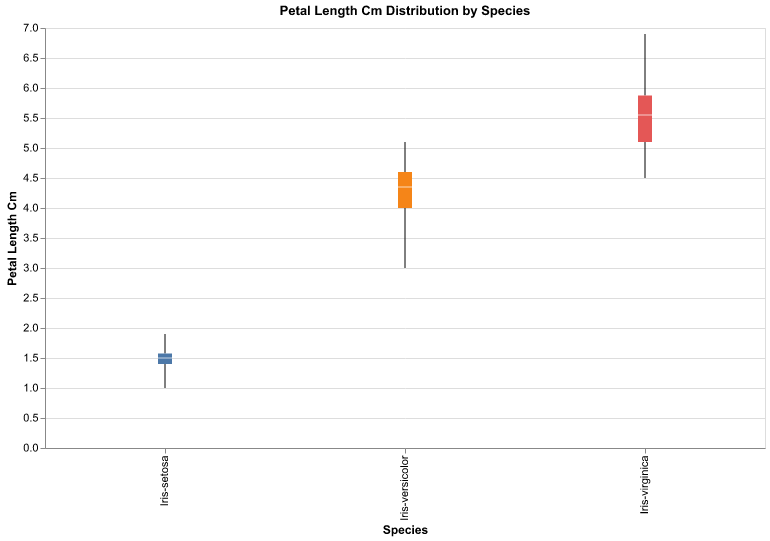

{
    'step': 'render_plot',
    'image_path': 'D:/programming/projects/ViRAGE/artifacts/notebooks/notebook_iris_demo_65d023bb/003_plot.png',
    'width': 770,
    'height': 541,
    'scenegraph': {
        'mark_type': 'rect,rule',
        'mark_types': ['rect', 'rule'],
        'marks_count': 12,
        'axes': ['axis', 'axis', 'axis'],
        'has_legend': False,
        'legend_count': 0,
        'notes': ['Rendered with Vega-Lite runtime via vl-convert-python.'],
        'source': 'vl-convert-python'
    },
    'notes': ['Rendered with Vega-Lite runtime via vl-convert-python.']
}

In [28]:
plot_rendering = VegaLitePlotDrawingService().invoke(
    spec_validation=spec_validation,
    run_id=RUN_ID,
    runtime=runtime,
)

display(Image(filename=plot_rendering.plot_image.image_path))

rprint({
    "step": "render_plot",
    "image_path": plot_rendering.plot_image.image_path,
    "width": plot_rendering.plot_image.width,
    "height": plot_rendering.plot_image.height,
    "scenegraph": plot_rendering.rendered_scenegraph,
    "notes": plot_rendering.render_notes,
})